# Preprocessing

The `preproc` stage turns a video into keyframes. It measures every frame, keeps the good ones,
picks a subset of them and saves it as a folder of PNGs that every later stage reads.

In [1]:
from IPython.display import Image, display

from collab_splats.preproc.frames import frame_idx_from_path, frame_paths, read_frames
from collab_splats.preproc.qa import load_video_quality
from collab_splats.preproc.sampling import (
    filter_frame_quality,
    sample_fps,
    sample_optical_flow,
    sample_uniform,
)
from collab_splats.preproc.viz import (
    plot_correlation,
    plot_frame_extremes,
    plot_frame_grid,
    plot_motion,
    plot_photometric,
    plot_selection,
)

%run ../tutorial.py

scene = tutorial_scene("preproc")

fps=2.000 wanted 199 frames, outside [min_frames=None, max_frames=96]; re-spread to 96 frames over the whole video (effective 0.964 fps)


## 1. Capture quality

The stage first measures the clip and saves the numbers in a quality report. It does not judge
frames yet. The measurements:

- `blur`: how soft the frame looks, 0 to 1; higher is blurrier.
- `laplacian`: amount of fine detail; higher is sharper.
- `clipped fraction`: share of pixels that are pure black or pure white.
- `translation`: how far the image content moved between two frames, in pixels.
- `parallax`: how much the viewpoint changed between two frames, 0 to 1. Depth needs parallax.
- `matches`: features found in both frames. Few matches means a fast turn or a blank view.

Load the report the stage saved, and the frames it kept:

In [2]:
report_path = scene.images_dir.parent / "video_quality_report.json"
report = load_video_quality(VIDEO_PATH, report_path)

# Source frame index of every kept keyframe
stored = frame_paths(scene.images_dir)
kept = [frame_idx_from_path(p) for p in stored]

# The plot functions write PNGs into this folder
plots_dir = work_dir("preprocessing")

Per-frame measurements over time; kept frames are marked:

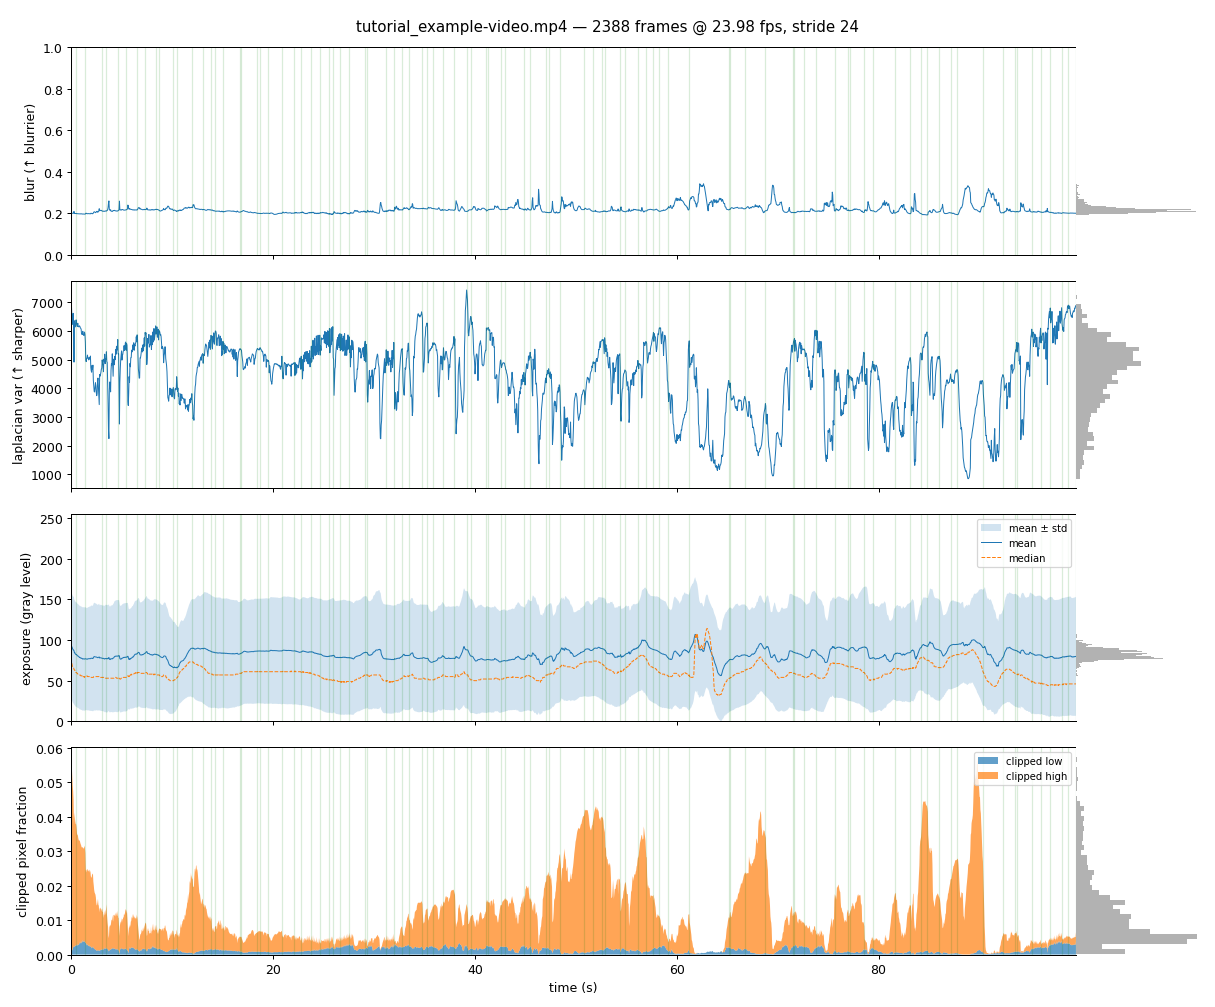

In [3]:
photometric_png = plot_photometric(report, plots_dir, selected=kept)
Image(filename=photometric_png)

Kept frames should avoid blur peaks and clipped-pixel spikes.

Motion between neighboring frames:

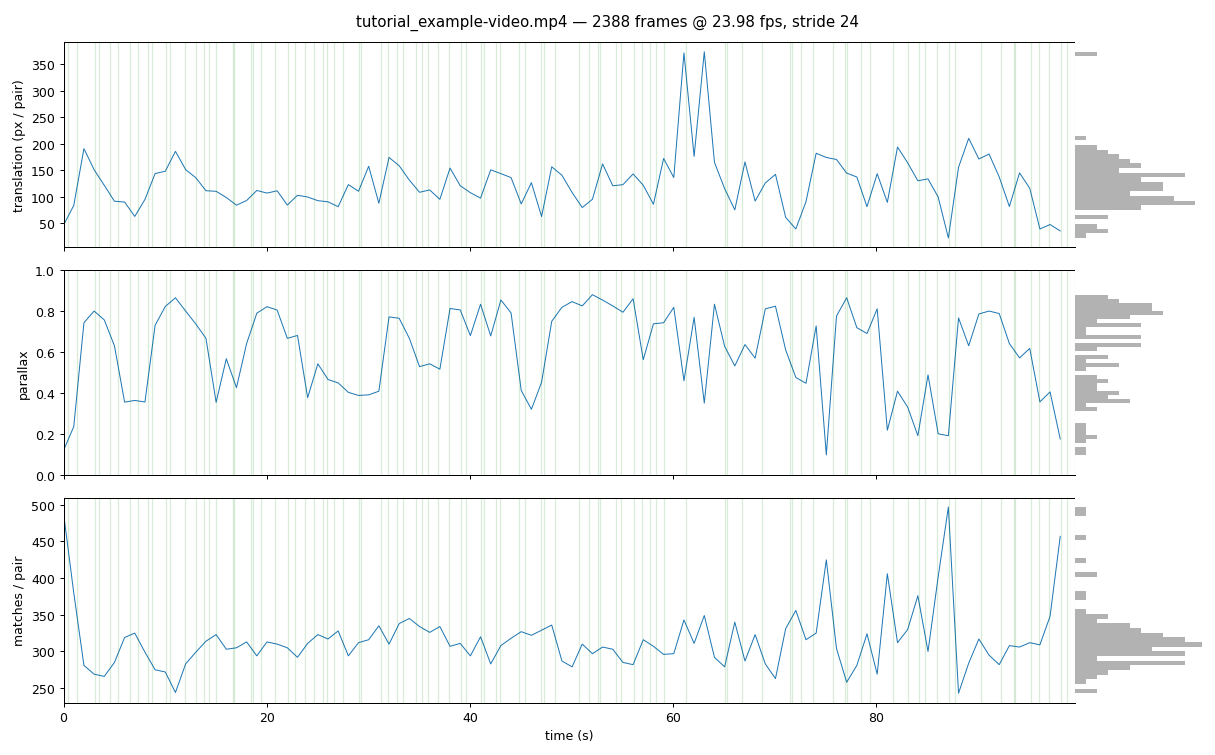

In [4]:
motion_png = plot_motion(report, plots_dir, selected=kept)
display(Image(filename=motion_png))

Stretches with few matches are where the camera turned fast or saw little texture.

Does fast motion cause blur? Blur of each pair's first frame against that pair's translation:

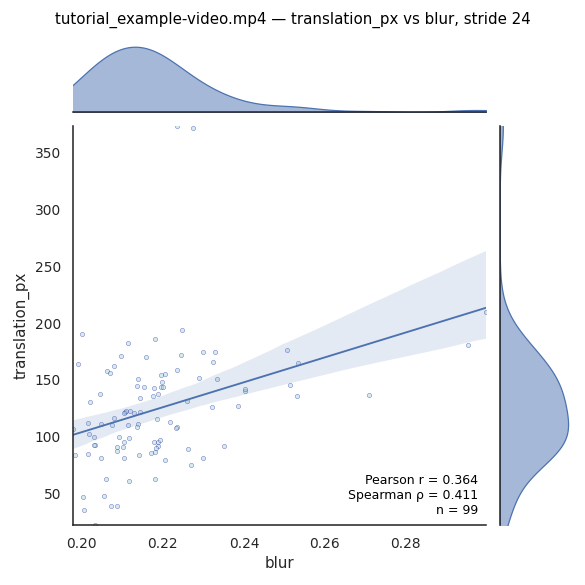

In [5]:
correlation_png = plot_correlation(report, "blur", "translation_px", plots_dir)
display(Image(filename=correlation_png))

A positive slope means faster motion gives blurrier frames on this clip.

What the blur numbers look like: the two blurriest and the two sharpest frames.

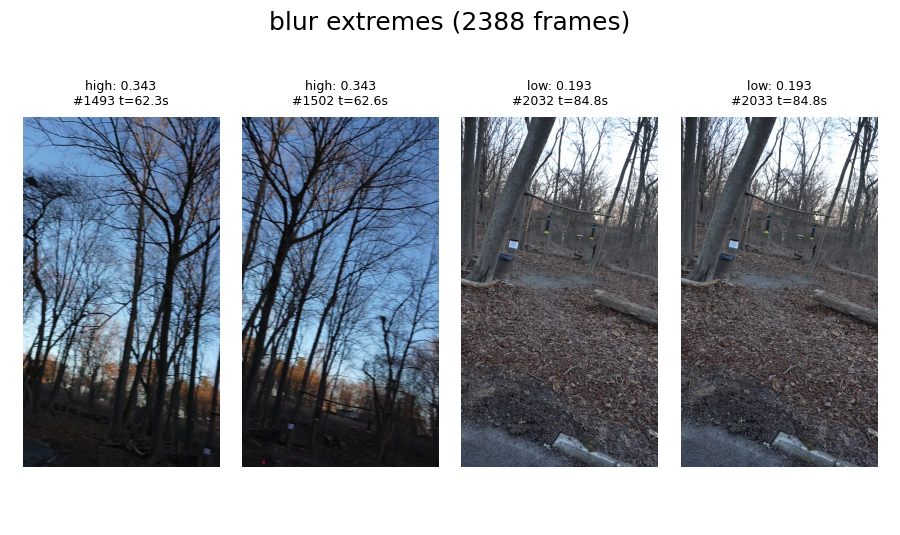

In [6]:
extremes_png = plot_frame_extremes(report, VIDEO_PATH, plots_dir, column="blur", n=2)
Image(filename=extremes_png)

Use these to decide which blur values you would still accept.

## 2. Choosing keyframes

`filter_frame_quality` decides which frames are good enough. It uses two thresholds:

- `sharpness_k`: drops frames much less sharp than the rest of this clip. Larger keeps more.
- `max_clipped_frac`: drops frames with too many pure black or white pixels.

The thresholds work on the saved report, so changing them does not decode the video again.

In [7]:
preproc_cfg = scene.config["preproc"]
max_frames = preproc_cfg["max_frames"]

# Default thresholds, as the stage used them
eligible = filter_frame_quality(report)
print(f"eligible: {eligible.sum()} / {eligible.size} frames")

eligible: 2041 / 2388 frames


Three samplers then pick keyframes from the eligible frames:

- `sample_fps` (default): the sharpest frame in each `1/fps`-second slot, so spacing is fixed.
- `sample_uniform`: exactly `max_frames` frames, evenly spaced.
- `sample_optical_flow`: a new frame each time the camera has moved enough. It stops at
  `max_frames`, so a small budget may cover only the start of the clip.

Run all three with the stage's settings and compare their picks:

fps=2.000 wanted 199 frames, outside [min_frames=None, max_frames=96]; re-spread to 96 frames over the whole video (effective 0.964 fps)


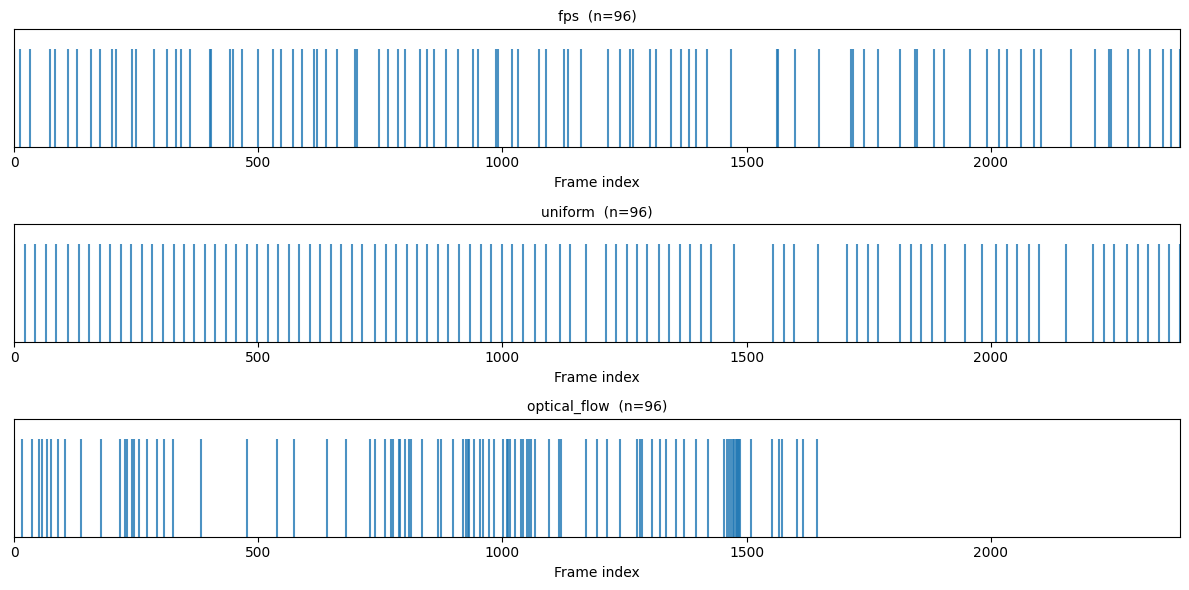

In [8]:
_, fps_records = sample_fps(
    str(VIDEO_PATH),
    fps=preproc_cfg["fps"],
    report=report,
    max_frames=max_frames,
    workers=preproc_cfg["n_workers"],
)
_, uniform_records = sample_uniform(
    str(VIDEO_PATH),
    max_frames=max_frames,
    report=report,
    workers=preproc_cfg["n_workers"],
)
_, flow_records = sample_optical_flow(
    str(VIDEO_PATH),
    report=report,
    max_frames=max_frames,
)

# One line per picked frame, one row per sampler
selections = {
    "fps": [r["frame_idx"] for r in fps_records],
    "uniform": [r["frame_idx"] for r in uniform_records],
    "optical_flow": [r["frame_idx"] for r in flow_records],
}
plot_selection(eligible.size, selections)

Each tick is one picked frame. Good picks spread over the whole clip.

## 3. The keyframe store

The stage saved its picks as `images/frame_NNNNNN.png`, named by the frame's index in the video.
Four of them:

96 keyframes in /workspace/collab-splats/.worktrees/tutorial-rework/data/tutorial_scene/images


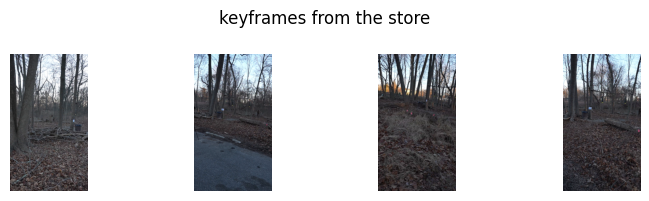

In [9]:
print(f"{len(stored)} keyframes in {scene.images_dir}")

# Four keyframes spread across the store
step = len(kept) // 4
montage = read_frames(scene.images_dir, kept[::step][:4])
plot_frame_grid(montage, title="keyframes from the store", n_cols=4)

Neighboring keyframes should overlap, so the same surfaces appear in several frames.

## 4. Lens distortion

Action-camera lenses bend straight lines. With `preproc.undistort: true` the stage estimates the
lens and rewrites the keyframes as if taken by a distortion-free camera. It is off by default.

## In a pipeline run

The `preproc` stage does all of this in one call. The keys, with their `configs/base.yaml`
defaults (this scene sets `max_frames: 96`):

```yaml
preproc:
  frame_selection: fps        # fps | uniform | optical_flow
  fps: 2.0                    # fps only: samples per second
  max_frames: 300             # count for uniform, ceiling otherwise
  undistort: false            # estimate the lens, then rewrite images/ undistorted
  # quality:                  # optional; module defaults shown
  #   sharpness_k: 2.0        # how much less sharp than the clip a frame may be
  #   max_clipped_frac: 0.25  # ceiling on the clipped-pixel fraction
```